# Hierarchical Bayesian calibration of the HTF thresholds

An alternative to the exact breakpoint search in `1. Direct_Search_Method.ipynb`. That
method solves each location **independently**, which fails exactly where the data is
thin: 64/175 locations had to **abstain** (fewer than 5 observed floods, or no in-sample
skill) and 14/111 produced a **physically impossible θ < 0**.

This model fixes that by **partial pooling** — every location borrows strength from its
coast, and the amount it borrows is decided by the data, not by a hand-set
`MIN_FLOOD_DAYS` rule.

### The model

For location `j` on day `i`, with `x` = daily peak NWM TWL (m, MHHW) and
`z = x − θ_ML_j` (water level measured from that location's ML baseline):

```
logit P(flood_ij) = a_j + β · z_ij            # varying intercept, linear in both unknowns
a_j               ~ Normal(μ_coast[j], σ_a)   # ← partial pooling within a coast
μ_coast           ~ Normal(μ_0, σ_coast)      # ← coasts pooled toward a global mean
μ_0               ~ Normal(0, 5)
σ_a, σ_coast      ~ HalfNormal(3), HalfNormal(2)
β                 ~ HalfNormal(3)             # steepness of the transition
```

`a_j` is the log-odds of flooding **at** the ML threshold, so the calibrated 50%
threshold comes out as `θ_j = θ_ML_j − a_j / β`. Writing the model this way — rather
than putting θ in the likelihood directly — keeps it linear in the parameters; the
direct form is multiplicative in β and θ and the sampler will not mix.

A location with 80 flood days is driven by its own data; one with 1 flood day is pulled
toward its coast's mean shift. That is the shrinkage the independent search cannot do.

Fit on **train** (≤ 2024-12-31), scored on the untouched **test** period (≥ 2025-01-01),
so it is directly comparable to `Outputs/Direct_Search/holdout_validation.csv`.


## 1. Imports + config

In [1]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")
RNG = 42

ROOT   = Path(".").resolve()
OUT    = Path("Outputs") / "Hierarchical_Bayes";  OUT.mkdir(parents=True, exist_ok=True)
DS     = Path("Outputs") / "Direct_Search"    # inputs from the direct-search run
MASTER = ROOT / "Inputs" / "Flood_Reference_Data" / "htf_master.csv"

TRAIN_END, TEST_START = "2024-12-31", "2025-01-01"
POSITIVE_SOURCES = ["flood_gfm", "flood_Groundsource", "TidsCurrents_minor"]
NEGATIVE_SOURCES = ["flood_gfm", "TidsCurrents_minor"]

# Cost weights must match optimization.ipynb so the two methods are compared fairly.
COST_FN, COST_FP = 2.0, 1.0

DRAWS, TUNE, CHAINS = 1000, 1000, 4
print(f"pymc {pm.__version__} | cost {COST_FN}:{COST_FP}")

# ---------------------------------------------------------------- NWM daily peak
NWM_TREE  = ROOT / "Inputs" / "NWM_Data" / "twl_buffer5km_nwm_aa_top5"
DATUM_COL = "value_m_mhhw"


def daily_twl(loc_id: int) -> pd.DataFrame:
    """Daily peak NWM TWL (m, MHHW) for one location, read from the per-day NWM
    files: nearest valid node at each timestamp, then the daily maximum."""
    d = NWM_TREE / f"loc{loc_id}"
    frames = []
    for f in (sorted(d.glob("*.csv")) if d.is_dir() else []):
        c = pd.read_csv(f, usecols=["valid_time_utc", "node_distance_km", DATUM_COL])
        c = c[c[DATUM_COL].notna()]
        if c.empty:
            continue
        frames.append(c.sort_values("node_distance_km")
                       .drop_duplicates("valid_time_utc", keep="first"))
    if not frames:
        return pd.DataFrame(columns=["date", "twl"])
    a = pd.concat(frames, ignore_index=True)
    a["date"] = pd.to_datetime(a.valid_time_utc).dt.tz_localize(None).dt.normalize()
    g = a.groupby("date")[DATUM_COL].max()
    return pd.DataFrame({"date": g.index, "twl": g.to_numpy()})


pymc 6.1.0 | cost 2.0:1.0


## 2. Assemble the train/test panel

In [2]:
def load_observed():
    usecols = ["location_id", "date"] + sorted(set(POSITIVE_SOURCES) | set(NEGATIVE_SOURCES))
    df = pd.read_csv(MASTER, usecols=usecols)
    df["date"] = pd.to_datetime(df["date"]).dt.normalize()
    pos = np.zeros(len(df), bool)
    for c in POSITIVE_SOURCES:
        pos |= df[c].fillna(0).to_numpy() > 0
    known = np.zeros(len(df), bool)
    for c in NEGATIVE_SOURCES:
        known |= df[c].notna().to_numpy()
    keep = known | pos
    return pd.DataFrame({"location_id": df.location_id[keep].astype(int),
                         "date": df.date[keep], "f": pos[keep].astype(int)})


observed = load_observed()
hold = pd.read_csv(DS / "holdout_validation.csv")          # the breakpoint-search result
thr  = pd.read_csv(DS / "optimized_thresholds.csv")
meta = pd.read_csv(ROOT / "Inputs" / "Flood_Reference_Data" / "per_point_summary.csv",
                   usecols=["location_id", "state", "coast"])

# same 175 locations that had a usable train/test split
locs = hold[hold.status.str.startswith(("ok", "abstain"))].location_id.astype(int).tolist()

frames = []
for loc in locs:
    t = daily_twl(loc)
    t["date"] = pd.to_datetime(t.date)
    m = t.merge(observed[observed.location_id == loc][["date", "f"]], on="date", how="inner")
    m["location_id"] = loc
    frames.append(m)
panel = pd.concat(frames, ignore_index=True).merge(meta, on="location_id", how="left")
panel["coast"] = panel.coast.fillna("Unknown")

train = panel[panel.date <= TRAIN_END].copy()
test  = panel[panel.date >= TEST_START].copy()
print(f"train {len(train):,} rows ({train.f.mean():.2%} positive) | "
      f"test {len(test):,} rows ({test.f.mean():.2%} positive) | {len(locs)} locations")

# index maps
loc_ids   = sorted(panel.location_id.unique())
loc_pos   = {l: i for i, l in enumerate(loc_ids)}
coasts    = sorted(panel.coast.unique())
coast_pos = {c: i for i, c in enumerate(coasts)}
loc_coast = (panel.groupby("location_id").coast.first().reindex(loc_ids)
             .map(coast_pos).to_numpy())
thr_ml    = (thr.set_index("location_id").thr_baseline.reindex(loc_ids).to_numpy())

train["li"] = train.location_id.map(loc_pos)
test["li"]  = test.location_id.map(loc_pos)
print(f"coasts: {dict(zip(coasts, np.bincount(loc_coast, minlength=len(coasts))))}")

train 56,344 rows (4.43% positive) | test 59,313 rows (2.37% positive) | 175 locations
coasts: {'East Coast': np.int64(89), 'Gulf of Mexico': np.int64(32), 'SE Florida': np.int64(22), 'West Coast': np.int64(32)}


## 3. Fit the hierarchical model (train only)

In [3]:
y_tr  = train.f.to_numpy()
li_tr = train.li.to_numpy()
# v2 reparametrization: VARYING-INTERCEPT logistic, LINEAR in the parameters.
#   logit p = a_j + beta * z ,   z = x - theta_ML_j   (centre at the ML threshold)
# a_j is the log-odds of flooding AT the ML threshold; beta the slope. Both enter
# linearly -> well-behaved geometry (v1 used beta*(x-theta_j), multiplicative in the two
# unknowns, which put theta on a likelihood plateau and never mixed). Recover the 50%
# threshold post-hoc: theta_j = theta_ML_j - a_j / beta.
z_tr = (train.twl.to_numpy() - thr_ml[li_tr])

with pm.Model(coords={"loc": loc_ids, "coast": coasts}) as model:
    beta = pm.HalfNormal("beta", sigma=3)                       # slope; tighter than v1

    # hierarchical INTERCEPT a_j ~ Normal(mu_coast, sigma_a), coasts pooled globally
    mu0         = pm.Normal("mu0", mu=0.0, sigma=5.0)           # global log-odds level
    sigma_coast = pm.HalfNormal("sigma_coast", sigma=2.0)
    z_coast     = pm.Normal("z_coast", 0.0, 1.0, dims="coast")          # non-centred
    mu_coast    = pm.Deterministic("mu_coast", mu0 + sigma_coast * z_coast, dims="coast")

    sigma_a     = pm.HalfNormal("sigma_a", sigma=3.0)
    z_a         = pm.Normal("z_a", 0.0, 1.0, dims="loc")               # non-centred
    a           = pm.Deterministic("a", mu_coast[loc_coast] + sigma_a * z_a, dims="loc")

    pm.Bernoulli("y", logit_p=a[li_tr] + beta * z_tr, observed=y_tr)

    # derived quantities (deterministic -> don't affect the sampling geometry)
    theta = pm.Deterministic("theta", thr_ml - a / beta, dims="loc")   # 50% threshold
    pm.Deterministic("delta", theta - thr_ml, dims="loc")              # calibration shift
    # coast-level shift for comparison with the empirical medians
    pm.Deterministic("mu_coast_shift", -mu_coast / beta, dims="coast")

    idata = pm.sample(draws=DRAWS, tune=TUNE, chains=CHAINS, target_accept=0.95,
                      random_seed=RNG, progressbar=False)

# NOTE: arviz 1.x formats summaries as STRINGS unless round_to=None, and renames the
# interval columns (eti89_lb/ub, not hdi_3%/hdi_97%).
print(az.summary(idata, var_names=["beta", "mu0", "sigma_coast", "sigma_a"],
                 round_to=None).round(3).to_string())

Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [beta, mu0, sigma_coast, z_coast, sigma_a, z_a]


Sampling 4 chains for 1_000 tune and 1_000 draw iterations (4_000 + 4_000 draws total) took 1013 seconds.


The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details


The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


             mean    sd  eti89_lb  eti89_ub  ess_bulk  ess_tail  r_hat  mcse_mean  mcse_sd
beta         16.0  0.28     16.00      17.0    2400.0    2600.0    1.0      0.006    0.004
mu0           2.2  1.40     -0.20       4.4     440.0     830.0    1.0      0.067    0.054
sigma_coast   2.5  1.10      0.92       4.4     140.0      87.0    1.0      0.086    0.067
sigma_a       9.8  0.53      9.00      11.0     180.0     450.0    1.0      0.040    0.029


## 4. Convergence check

In [4]:
summ = az.summary(idata, var_names=["beta", "mu0", "sigma_coast", "sigma_a",
                                    "mu_coast", "a", "theta"], round_to=None)
print(f"parameters with r_hat > 1.01 : {(summ.r_hat > 1.01).sum()} / {len(summ)}")
print(f"parameters with ess_bulk<400 : {(summ.ess_bulk < 400).sum()} / {len(summ)}")
try:
    print(f"divergences: {int(idata.sample_stats.diverging.sum())}")
except Exception:
    print("divergences: (not reported by this backend)")

print("\ncoast mean shift μ_coast (m) — compare with the empirical medians:")
mc = az.summary(idata, var_names=["mu_coast_shift"], round_to=None)
keep = [c for c in ["mean", "sd", "eti89_lb", "eti89_ub", "r_hat"] if c in mc.columns]
print(mc[keep].round(3).to_string())

parameters with r_hat > 1.01 : 2 / 358
parameters with ess_bulk<400 : 6 / 358
divergences: 0

coast mean shift μ_coast (m) — compare with the empirical medians:
                                 mean     sd  eti89_lb  eti89_ub  r_hat
mu_coast_shift[East Coast]     -0.200  0.060     -0.30    -0.110    1.1
mu_coast_shift[Gulf of Mexico] -0.270  0.100     -0.45    -0.120    1.0
mu_coast_shift[SE Florida]     -0.170  0.094     -0.32    -0.021    1.0
mu_coast_shift[West Coast]      0.067  0.120     -0.13     0.250    1.1


## 5. Turn the posterior into an operational threshold

`θ_j` is the **50%** threshold. To match the cost-weighted breakpoint search we flag a
day when `P(flood) > p*`, where `p* = COST_FP / (COST_FN + COST_FP)`. On the logit scale
that shifts the cut:

```
θ_operational = θ_50 + logit(p*) / β
```

With 2:1 costs, `p* = 1/3`, so the operational threshold sits `0.69/β` **below** the 50%
threshold — the asymmetric cost buys recall, exactly as in the other notebook.

In [5]:
post   = idata.posterior
theta50 = post["theta"].mean(("chain", "draw")).to_numpy()
beta_m  = float(post["beta"].mean())
p_star  = COST_FP / (COST_FN + COST_FP)
theta_op = theta50 + np.log(p_star / (1 - p_star)) / beta_m

bayes = pd.DataFrame({
    "location_id": loc_ids, "thr_baseline": thr_ml,
    "theta50_bayes": theta50, "theta_op_bayes": theta_op,
    "shift_bayes": theta_op - thr_ml,
    "coast": [coasts[c] for c in loc_coast],
    "n_pos_train": train.groupby("li").f.sum().reindex(range(len(loc_ids))).fillna(0).to_numpy(),
})
print(f"β = {beta_m:.2f}  (transition width ≈ {1/beta_m:.3f} m)   p* = {p_star:.2f}")
print(f"θ_op − θ_50 = {np.log(p_star/(1-p_star))/beta_m:+.3f} m")
print(f"\nnegative θ (physically implausible): {(bayes.theta_op_bayes < 0).sum()} / {len(bayes)}")
bayes.head()

β = 16.09  (transition width ≈ 0.062 m)   p* = 0.33
θ_op − θ_50 = -0.043 m

negative θ (physically implausible): 13 / 175


,location_id,thr_baseline,theta50_bayes,theta_op_bayes,shift_bayes,coast,n_pos_train
0,8,0.531855,0.523767,0.480692,-0.051163,West Coast,12
1,10,0.409937,0.343471,0.300395,-0.109542,West Coast,6
2,61,0.452522,0.406262,0.363186,-0.089336,West Coast,8
3,66,0.452522,0.435231,0.392155,-0.060367,West Coast,8
4,78,0.396706,0.291979,0.248903,-0.147803,West Coast,22


## 6. Score on the untouched test period & compare with the breakpoint search

In [6]:
def confusion(pred, obs):
    tp = int(np.sum(pred & obs));  fp = int(np.sum(pred & ~obs))
    fn = int(np.sum(~pred & obs)); tn = int(np.sum(~pred & ~obs))
    return tp, fp, fn, tn


def skill(cm):
    tp, fp, fn, tn = cm
    rec  = tp / (tp + fn) if (tp + fn) else 0.0
    prec = tp / (tp + fp) if (tp + fp) else 0.0
    f1   = 2 * prec * rec / (prec + rec) if (prec + rec) else 0.0
    tnr  = tn / (tn + fp) if (tn + fp) else 0.0
    return {"TP": tp, "FP": fp, "FN": fn, "TN": tn, "recall": rec,
            "precision": prec, "F1": f1, "youden": rec + tnr - 1}


x_te, y_te, li_te = test.twl.to_numpy(), test.f.to_numpy().astype(bool), test.li.to_numpy()

rows = {}
rows["BEFORE (ML θ)"]        = skill(confusion(x_te > thr_ml[li_te], y_te))
rows["Breakpoint search"]    = None      # filled below from holdout_validation.csv
rows["Hierarchical Bayes"]   = skill(confusion(x_te > theta_op[li_te], y_te))

# breakpoint-search thresholds on the same rows (abstained locations keep θ_ML)
bp = hold.set_index("location_id").thr_opt.reindex(loc_ids).to_numpy()
rows["Breakpoint search"] = skill(confusion(x_te > bp[li_te], y_te))

cmp = pd.DataFrame(rows).T[["TP", "FP", "FN", "TN", "recall", "precision", "F1", "youden"]]
cmp[["recall", "precision", "F1", "youden"]] = cmp[["recall", "precision", "F1", "youden"]].astype(float).round(3)
print("OUT-OF-SAMPLE (test ≥ 2025-01-01), same 175 locations:\n")
print(cmp.to_string())

bayes["thr_breakpoint"] = bp
bayes.to_csv(OUT / "hierarchical_bayes_thresholds.csv", index=False)
cmp.to_csv(Path("Outputs") / "method_comparison.csv")
print(f"\nwrote {OUT}/hierarchical_bayes_thresholds.csv and Outputs/method_comparison.csv")

OUT-OF-SAMPLE (test ≥ 2025-01-01), same 175 locations:

                       TP      FP      FN       TN  recall  precision     F1  youden
BEFORE (ML θ)       289.0  1686.0  1117.0  56221.0   0.206      0.146  0.171   0.176
Breakpoint search   888.0  1943.0   518.0  55964.0   0.632      0.314  0.419   0.598
Hierarchical Bayes  747.0   692.0   659.0  57215.0   0.531      0.519  0.525   0.519

wrote Outputs/Hierarchical_Bayes/hierarchical_bayes_thresholds.csv and Outputs/method_comparison.csv


## 7. Does pooling actually help the sparse locations?

In [7]:
b = bayes.copy()
b["bucket"] = pd.cut(b.n_pos_train, [0, 4, 10, 25, 1e9],
                     labels=["1-4 (abstained before)", "5-10", "11-25", ">25"])
print("out-of-sample F1 by number of TRAIN flood days:\n")
print(f"{'bucket':>24}{'locs':>6}{'breakpoint F1':>15}{'Bayes F1':>10}")
for bk, g in b.groupby("bucket"):
    if not len(g):
        continue
    sel = np.isin(li_te, [loc_pos[l] for l in g.location_id])
    f_bp = skill(confusion(x_te[sel] > bp[li_te[sel]], y_te[sel]))["F1"]
    f_by = skill(confusion(x_te[sel] > theta_op[li_te[sel]], y_te[sel]))["F1"]
    print(f"{str(bk):>24}{len(g):>6}{f_bp:>15.3f}{f_by:>10.3f}")

print("\nshrinkage — |shift| vs evidence (sparse sites should sit near their coast mean):")
print(b.groupby("bucket").agg(locs=("shift_bayes", "size"),
                              median_shift_bayes=("shift_bayes", "median"),
                              median_shift_bp=("thr_breakpoint", "median")).round(3).to_string())

out-of-sample F1 by number of TRAIN flood days:

                  bucket  locs  breakpoint F1  Bayes F1
  1-4 (abstained before)    58          0.181     0.219
                    5-10    24          0.565     0.513
                   11-25    62          0.379     0.563
                     >25    31          0.539     0.565

shrinkage — |shift| vs evidence (sparse sites should sit near their coast mean):
                        locs  median_shift_bayes  median_shift_bp
bucket                                                           
1-4 (abstained before)    58              -0.129            0.531
5-10                      24              -0.193            0.354
11-25                     62              -0.284            0.231
>25                       31              -0.454            0.162


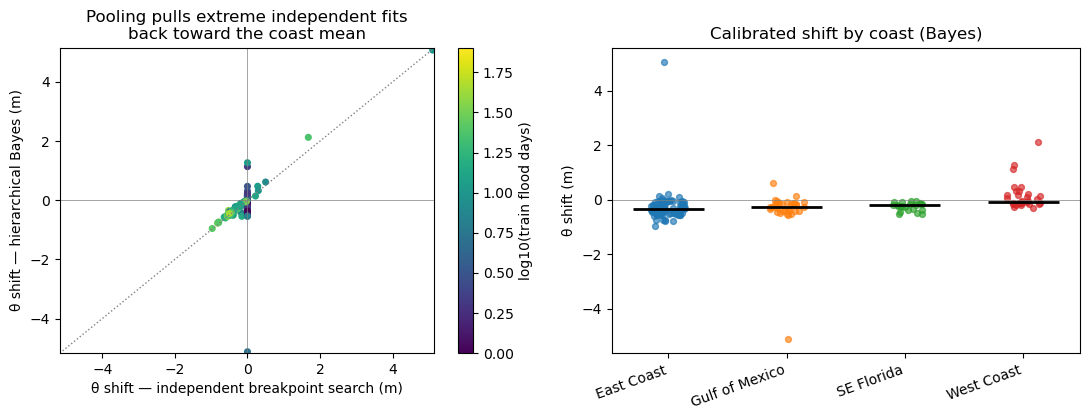

In [8]:
# Shrinkage picture: Bayes vs independent breakpoint search, sized by evidence
fig, ax = plt.subplots(1, 2, figsize=(11, 4.3))

b2 = bayes.copy()
b2["shift_bp"] = b2.thr_breakpoint - b2.thr_baseline
sc = ax[0].scatter(b2.shift_bp, b2.shift_bayes, c=np.log10(b2.n_pos_train.clip(lower=1)),
                   cmap="viridis", s=26, edgecolor="none")
lim = [min(b2.shift_bp.min(), b2.shift_bayes.min()) - .05,
       max(b2.shift_bp.max(), b2.shift_bayes.max()) + .05]
ax[0].plot(lim, lim, ls=":", c="grey", lw=1)
ax[0].axhline(0, c="grey", lw=.5); ax[0].axvline(0, c="grey", lw=.5)
ax[0].set(xlim=lim, ylim=lim, xlabel="θ shift — independent breakpoint search (m)",
          ylabel="θ shift — hierarchical Bayes (m)",
          title="Pooling pulls extreme independent fits\nback toward the coast mean")
plt.colorbar(sc, ax=ax[0], label="log10(train flood days)")

for i, c in enumerate(coasts):
    g = bayes[bayes.coast == c]
    ax[1].scatter(np.full(len(g), i) + np.random.uniform(-.15, .15, len(g)),
                  g.shift_bayes, s=18, alpha=.65)
    ax[1].hlines(g.shift_bayes.median(), i - .3, i + .3, color="k", lw=2)
ax[1].set_xticks(range(len(coasts)))
ax[1].set_xticklabels(coasts, rotation=20, ha="right")
ax[1].axhline(0, c="grey", lw=.5)
ax[1].set(ylabel="θ shift (m)", title="Calibrated shift by coast (Bayes)")
fig.tight_layout()
plt.show()
